# D.R.O.N.A. — 04 · Model Training (Colab A100)

Trains every learned model in the system, from simple baselines to the
state-of-the-art policies, with fixed seeds, TensorBoard tracking, and
checkpointing.

```
01 data cleaning  ->  02 EDA  ->  03 feature engineering  ->  04 model training  ->  05 evaluation
   & preprocessing                   (dual embeddings)          (Colab A100)          & comparison
```

**Runtime:** **A100 GPU strongly recommended** (Runtime ▸ Change runtime type ▸
A100). Everything falls back to T4/QLoRA settings automatically. Total wall
time on an A100: **≈ 45-60 min** with all flags on.

## What gets trained, and why these models

| Part | Model | Class | Why it is the right choice |
|---|---|---|---|
| A | **Qwen3-4B-Instruct-2507 + LoRA** | advising LLM | Strongest ~4B open instruct model (Apache-2.0) that still serves on the student's local CPU (Ollama Q4) or any GPU (transformers backend) - the project constraint is *local, no paid APIs*. LoRA bf16 on A100 / QLoRA 4-bit on T4, `all-linear` targets (Dettmers et al. 2023). Phi-3.5-mini remains a one-line swap |
| B0 | **Keyframe policy** | handcrafted baseline | The floor every learned policy must beat (C3) |
| B1 | **Behaviour-cloning MLP** | learned baseline | Simplest learnable mapping; exposes regression-to-mean, motivating action chunking. Exported to **ONNX/TorchScript** for robot deployment (B.1b) |
| B2 | **ACT** (Zhao et al. 2023) | state of the art | Action-chunking transformer - the standard for low-data imitation learning; the C3 headline model |
| B3 | **Diffusion Policy** (Chi et al. 2023) | state of the art | Multimodal action distributions; the ablation competitor to ACT |

Retrieval (C1) has no trainable weights - its "training" is the embedding +
indexing done in notebook 03, and its hyperparameters are swept in notebook 05.

**How long does it take?**

| Part | A100 | T4 (free tier) |
|---|---|---|
| A · LLM LoRA (Qwen3-4B) | ~12-18 min | ~45-75 min (QLoRA) |
| B.1 · BC baseline + ONNX export | ~3 min | ~4 min |
| B.2 · ACT (20k steps) | ~10-15 min | ~30-45 min |
| B.3 · Diffusion (30k steps) | ~20-30 min | ~60-90 min |
| **Total** | **~45-70 min** | **~2.5-3.5 h** |

**Crash-safe & resumable:** Colab sessions can disconnect. The persistence
cell below copies every finished part to **Google Drive immediately** and, on
a fresh session, restores them and **skips completed parts**. If the runtime
dies: reconnect → `Runtime ▸ Run all` → only the unfinished part trains.
On the free T4, consider `TRAIN_DIFFUSION = False` for the first pass and add
the ablation model in a second session - the resume logic makes that free.

**Reproducibility:** fixed seeds everywhere, config dataclass printed and saved
next to each checkpoint, library versions frozen to `reports/train_env.txt`.

## 0 · Colab setup

In [1]:
# ===========================================================================
#  D.R.O.N.A. - Colab setup.  *** RUN THIS CELL FIRST ***
#  Target: Google Colab with an A100 GPU (Runtime > Change runtime type).
#  Part A trains in bf16 on the A100; on a T4 it falls back to 4-bit QLoRA.
# ===========================================================================
import os, sys, subprocess, pathlib

gpu = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout.strip()
print(gpu or "No GPU detected - see the note at the top of this notebook.")

# EDIT this to your GitHub repo URL. Private repo? use a fine-grained read
# token: https://<TOKEN>@github.com/<user>/D.R.O.N.A.git
# Alternatively upload a zip of the project (Colab Files panel) or attach it
# as a Kaggle dataset named 'drona' - the search loop below finds it.
REPO_URL = "https://github.com/trishan9/D.R.O.N.A.git"   # <-- EDIT ME

def _is_repo(p):
    return pathlib.Path(p, "drona", "__init__.py").is_file()

search = [".", "..", "../..", "D.R.O.N.A", "/content/D.R.O.N.A",
          "/kaggle/working/D.R.O.N.A", "/kaggle/input/drona/D.R.O.N.A", "/kaggle/input/drona"]
repo = next((p for p in search if _is_repo(p)), None)
if repo is None:
    dest = "/content/D.R.O.N.A" if pathlib.Path("/content").is_dir() else "D.R.O.N.A"
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, dest], check=True)
    repo = dest
assert repo and _is_repo(repo), (
    "Repo not found. Set REPO_URL to your GitHub URL, OR upload/attach the "
    "project, then re-run. See docs/COLAB_TRAINING_GUIDE.md.")
os.chdir(repo)
print("repo:", os.getcwd())

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[eval]"], check=False)

# If Colab cannot reach huggingface.co (downloads stall forever at N%), set
# this True to route all model downloads through the hf-mirror.com mirror.
USE_HF_MIRROR = False
if USE_HF_MIRROR:
    os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
    print("routing HF downloads via hf-mirror.com")

# Robust, resumable HF downloads - plain Colab downloads stall (e.g. hang at
# 57%, then restart lower on retry). hf_transfer pulls shards in parallel and
# resumes properly, so the ~8GB Qwen base downloads reliably.
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "hf_transfer"], check=False)
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "60"
# Use an HF token from Colab Secrets (key icon: name it HF_TOKEN) to avoid the
# anonymous rate limits that throttle downloads on Colab's shared IPs.
try:
    from google.colab import userdata as _ud
    _tok = _ud.get("HF_TOKEN")
    if _tok:
        os.environ["HF_TOKEN"] = _tok
        print("HF token loaded from Colab Secrets - authenticated downloads")
except Exception:
    pass
print("setup complete - continue to the next cell")

GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-559dc030-c7b1-d41e-557b-64c899abd633)
repo: /content/D.R.O.N.A
HF token loaded from Colab Secrets - authenticated downloads
setup complete - continue to the next cell


In [2]:
# ── Load & VERIFY the real private data (curriculum) — RUN AFTER SETUP ────────
# The real curriculum ships separately in drona_private_data.zip (it is
# gitignored). This cell puts it into the repo and HARD-STOPS on placeholder
# data, so you never train on dummies. It uses a DIRECT in-notebook upload
# (no Google Drive needed): the file picker BLOCKS this cell until you choose the
# zip, so later cells cannot run without the data. Re-running is safe — once the
# data is present it does nothing.
import glob, os, pathlib, subprocess

REPO = next((p for p in (".", "/content/D.R.O.N.A", "D.R.O.N.A", "..")
             if pathlib.Path(p, "drona", "__init__.py").is_file()), ".")

def _real_curriculum_count():
    d = pathlib.Path(REPO, "data/raw/curriculum")
    files = list(d.glob("*.md")) if d.is_dir() else []
    return sum(1 for f in files
               if "DUMMY / PLACEHOLDER" not in f.read_text(encoding="utf-8", errors="ignore")[:200])

def _unzip(z):
    print("unzipping", z, "...")
    subprocess.run(["unzip", "-oq", z, "-d", REPO], check=True)

if _real_curriculum_count() >= 40:
    print(f"real curriculum already present ({_real_curriculum_count()} modules) - OK to proceed")
else:
    # Reuse a bundle already on disk (Files-panel upload, Drive, or a prior run).
    found = (glob.glob("drona_private_data.zip")
             + glob.glob("/content/drona_private_data.zip")
             + glob.glob(f"{REPO}/drona_private_data.zip")
             + glob.glob("../drona_private_data.zip")
             + glob.glob("/content/drive/MyDrive/**/drona_private_data.zip", recursive=True)
             + glob.glob("/kaggle/input/**/drona_private_data.zip", recursive=True))
    if found:
        _unzip(found[0])
    else:
        try:
            from google.colab import files
        except ImportError:
            files = None
        if files is not None:
            print("\n" + "=" * 64)
            print(">>> Upload drona_private_data.zip now — click 'Choose Files'. <<<")
            print("    It is in your project folder on your PC (~4 MB).")
            print("=" * 64 + "\n")
            uploaded = files.upload()          # BLOCKS until the upload finishes
            zname = next((n for n in uploaded if n.lower().endswith(".zip")), None)
            if zname:
                if not os.path.exists(zname):
                    pathlib.Path(zname).write_bytes(uploaded[zname])
                _unzip(zname)

    n = _real_curriculum_count()
    if n < 40:
        raise SystemExit(
            f"\n*** REAL CURRICULUM NOT LOADED (only {n} real module files) ***\n"
            "Re-run THIS cell and upload drona_private_data.zip when the picker appears.")
    print(f"real curriculum loaded: {n} module files across all programmes - OK to proceed")



>>> Upload drona_private_data.zip now — click 'Choose Files'. <<<
    It is in your project folder on your PC (~4 MB).



Saving drona_private_data.zip to drona_private_data.zip
unzipping drona_private_data.zip ...
real curriculum loaded: 87 module files across all programmes - OK to proceed


### GPU optimisation

In [3]:
import torch

assert torch.cuda.is_available(), "No GPU - select one under Runtime > Change runtime type."
name = torch.cuda.get_device_name(0)
cap = torch.cuda.get_device_capability(0)
vram = torch.cuda.get_device_properties(0).total_memory / 1e9

# TF32 matmuls: free ~2x speedup on Ampere+ (A100) at negligible precision cost.
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

BF16_OK = cap >= (8, 0)          # Ampere or newer -> native bfloat16
print(f"{name} | {vram:.0f} GB | compute {cap} | bf16 native: {BF16_OK}")
if not BF16_OK:
    print("older GPU detected -> Part A will use 4-bit QLoRA settings")

NVIDIA A100-SXM4-40GB | 42 GB | compute (8, 0) | bf16 native: True


In [4]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers>=4.44", "peft>=0.12", "trl>=0.12",
                "accelerate>=0.33", "datasets>=2.18", "bitsandbytes>=0.43",
                "tensorboard", "onnx>=1.16", "onnxruntime>=1.17"], check=True)
# NOTE: LeRobot is deliberately NOT installed here. lerobot 0.3.3 pins
# torch<2.8 / torchvision<0.23, which clashes with Colab's default torch and
# breaks the LLM stack (Qwen fails with a torchvision circular import). It is
# installed later, in Part B, so the LLM here uses Colab's matched torch.
print("Part A (LLM) training + export dependencies installed")

Part A (LLM) training + export dependencies installed


In [5]:
# Ensure the processed artifacts from notebook 01 exist; regenerate if missing.
import pathlib, subprocess, sys

needed = ["data/processed/onet_career_pathways.parquet",
          "data/processed/onet_career_pathways.json",
          "data/processed/curriculum_modules.json",
          "data/processed/manual_postings.json",
          "data/finetune/sft_train.jsonl",
          "data/demonstrations/demonstrations.jsonl"]
missing = [p for p in needed if not pathlib.Path(p).exists()]
if missing:
    print("missing artifacts:", *missing, sep="\n  ")
    # If the processed O*NET is already here (from the data bundle / nb01), do NOT
    # re-download it - Colab's route to the O*NET site is flaky and can leave a
    # corrupt cached zip. --skip-onet regenerates the rest from the cached anchors.
    args = [sys.executable, "scripts/prepare_training_data.py"]
    if pathlib.Path("data/processed/onet_career_pathways.parquet").exists():
        args.append("--skip-onet")
    print("regenerating with", " ".join(args[1:]), "...")
    subprocess.run(args, check=True)
print("all pipeline inputs present")


all pipeline inputs present


In [6]:
# ── Crash-safe training: Google Drive persistence + resume ──────────────────
# Colab sessions can disconnect (idle timeout / free-tier preemption). This
# cell makes the notebook RESUMABLE: every finished part is copied to Drive
# immediately, and on a fresh session artifacts are restored so completed
# parts are SKIPPED. After a crash: reconnect, Runtime > Run all - only the
# unfinished part retrains.

import pathlib, shutil

SAVE_TO_DRIVE = True      # strongly recommended on Colab (asks for auth once)
FORCE_RETRAIN = False     # True = retrain everything even if artifacts exist

DRIVE = None
if SAVE_TO_DRIVE:
    try:
        from google.colab import drive as _gdrive
        _gdrive.mount("/content/drive")
        DRIVE = pathlib.Path("/content/drive/MyDrive/drona_training")
        DRIVE.mkdir(parents=True, exist_ok=True)
        print("Drive persistence ON ->", DRIVE)
    except Exception as exc:
        print(f"Drive not available ({exc}) - artifacts stay on the VM only. "
              "Download the final zip before the session ends!")

def persist(local: str) -> None:
    """Copy an artifact dir/file to Drive right after it is produced."""
    if DRIVE is None:
        return
    src = pathlib.Path(local)
    dst = DRIVE / local
    if src.is_dir():
        shutil.copytree(src, dst, dirs_exist_ok=True)
    elif src.is_file():
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
    print(f"  persisted -> {dst}")

def restore(local: str) -> bool:
    """Bring an artifact back from Drive if this VM does not have it."""
    src_local = pathlib.Path(local)
    if src_local.exists() or DRIVE is None:
        return src_local.exists()
    dst = DRIVE / local
    if dst.exists():
        if dst.is_dir():
            shutil.copytree(dst, src_local, dirs_exist_ok=True)
        else:
            src_local.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(dst, src_local)
        print(f"  restored <- {dst}")
        return True
    return False

# Restore anything a previous session already finished
for artifact in ("models/advising-lora", "data/checkpoints/bc",
                 "data/checkpoints/act", "data/checkpoints/diffusion",
                 "reports/sft_metrics.json"):
    restore(artifact)

def _done(path, marker=None):
    p = pathlib.Path(path)
    if marker:
        p = p / marker
    return p.exists() and not FORCE_RETRAIN

SKIP_SFT  = _done("models/advising-lora", "adapter_config.json")
SKIP_BC   = _done("data/checkpoints/bc", "greet/pytorch_model.bin")
SKIP_ACT  = bool(list(pathlib.Path("data/checkpoints/act").rglob("*.safetensors"))) and not FORCE_RETRAIN if pathlib.Path("data/checkpoints/act").exists() else False
SKIP_DIFF = bool(list(pathlib.Path("data/checkpoints/diffusion").rglob("*.safetensors"))) and not FORCE_RETRAIN if pathlib.Path("data/checkpoints/diffusion").exists() else False
print(f"resume state: SFT done={SKIP_SFT} | BC done={SKIP_BC} | "
      f"ACT done={SKIP_ACT} | Diffusion done={SKIP_DIFF}")


Drive not available (mount failed) - artifacts stay on the VM only. Download the final zip before the session ends!
resume state: SFT done=False | BC done=False | ACT done=False | Diffusion done=False


In [7]:
# --- Shared plotting style: colorblind-safe palette, publication defaults ----
import random, pathlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Categorical palette - CVD-validated ordering. Never reorder or cycle it;
# a 9th series folds into "other".
C = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
     "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "axis": "#c3c2b7", "surface": "#fcfcfb"}
SEQ = LinearSegmentedColormap.from_list("drona_seq",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("drona_div",
    ["#104281", "#5598e7", "#f0efec", "#e88a89", "#a52827"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
    "axes.edgecolor": INK["axis"], "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": INK["grid"], "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.labelcolor": INK["secondary"], "axes.labelsize": 10,
    "xtick.color": INK["muted"], "ytick.color": INK["muted"],
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "text.color": INK["primary"], "font.family": "sans-serif",
    "legend.frameon": False, "legend.fontsize": 9,
    "axes.prop_cycle": mpl.cycler(color=C),
})

FIG_DIR = pathlib.Path("reports/figures/04_training")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def finish(ax, title, subtitle=None, xlabel=None, ylabel=None, grid_axis="y"):
    """Standard title/label treatment. grid_axis: which axis keeps gridlines."""
    ax.set_title(title, pad=22 if subtitle else 8)
    if subtitle:
        ax.text(0, 1.03, subtitle, transform=ax.transAxes,
                fontsize=9, color=INK["secondary"])
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(visible=False, axis="x" if grid_axis == "y" else "y")
    return ax

def save_fig(fig, name):
    p = FIG_DIR / f"{name}.png"
    fig.savefig(p)
    print(f"figure saved -> {p}")

print("plot style ready; figures ->", FIG_DIR)

plot style ready; figures -> reports/figures/04_training


---
# Part A · LoRA fine-tune of the advising LLM

Base model: **Qwen3-4B-Instruct-2507** (Apache-2.0) - the strongest ~4B open
instruct model, chosen because it must still serve **locally** on the student
PC (no paid APIs, contribution C4). The previous default (Phi-3.5-mini) is a
one-line swap in the cell below; `target_modules="all-linear"` makes the LoRA
architecture-agnostic.

On the **A100** the base model loads in full **bf16** (no quantisation error,
~1.5-2x faster steps); `USE_QLORA` flips everything back to the 4-bit T4
recipe. Effective batch size stays 16 in both modes so runs are comparable.

In [8]:
from drona.finetune.lora_config import DronaLoraConfig

# ── Base model ───────────────────────────────────────────────────────────────
# Qwen3-4B-Instruct-2507: strongest ~4B open instruct model (Apache-2.0),
# non-thinking variant (clean JSON output), serves locally via Ollama at Q4
# or directly via the transformers backend (LLM_BACKEND=transformers).
# target_modules="all-linear" adapts LoRA to ANY architecture, so swapping
# the base model needs no other change.
BASE_MODEL = "Qwen/Qwen3-4B-Instruct-2507"
# BASE_MODEL = "microsoft/Phi-3.5-mini-instruct"   # previous default (MIT)
# BASE_MODEL = "meta-llama/Llama-3.2-3B-Instruct"  # needs HF license acceptance

USE_QLORA = not BF16_OK      # A100 -> False (bf16 LoRA). T4/small GPU -> True (QLoRA).

cfg = DronaLoraConfig(base_model=BASE_MODEL)
if not USE_QLORA:
    cfg.load_in_4bit = False
    cfg.per_device_train_batch_size = 8    # A100 headroom
    cfg.gradient_accumulation_steps = 2    # effective batch stays 16

print(f"base={cfg.base_model}\nQLoRA={USE_QLORA} | r={cfg.r} alpha={cfg.lora_alpha} "
      f"dropout={cfg.lora_dropout} | targets={cfg.target_modules}\n"
      f"batch={cfg.per_device_train_batch_size}x{cfg.gradient_accumulation_steps} "
      f"(effective {cfg.effective_batch_size}) | lr={cfg.learning_rate} "
      f"| epochs={cfg.num_train_epochs} | seed={cfg.seed}\noutput -> {cfg.output_dir}")

base=Qwen/Qwen3-4B-Instruct-2507
QLoRA=False | r=16 alpha=32 dropout=0.05 | targets=all-linear
batch=8x2 (effective 16) | lr=0.0002 | epochs=3 | seed=230352
output -> models/advising-lora


In [9]:
import json
from datasets import Dataset

train_raw = [json.loads(l) for l in open("data/finetune/sft_train.jsonl", encoding="utf-8")]
val_raw   = [json.loads(l) for l in open("data/finetune/sft_val.jsonl", encoding="utf-8")]
train_ds = Dataset.from_list([{"messages": e["messages"]} for e in train_raw])
val_ds   = Dataset.from_list([{"messages": e["messages"]} for e in val_raw])
print(f"SFT train={len(train_ds)} val={len(val_ds)}")
print(train_raw[0]["messages"][1]["content"][:220])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/constants.py:298: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


SFT train=576 val=63

RETRIEVED DOCUMENTS (cite by number [N]):
[1] [NEPAL] job_posting | id:me_201690
    Front Desk Associate at Nana Holiday Homes - skills: Communication, Teamwork, Customer Support, Front Desk Management, Guest Service M


In [10]:
# ── Robust base-model download: aria2c, alternating endpoints, Drive-persisted ─
# Colab's route to HF stalls on the ~8GB base model. aria2c (many connections +
# resume) claws each file through, and we ALTERNATE the mirror and real HF per
# retry so if one throttles a shard, the other serves it. Saved to Google Drive
# so it only has to succeed ONCE; training then loads the local copy (no HF).
if not SKIP_SFT:
    import os, time, subprocess, pathlib
    LOCAL = pathlib.Path("/content/base_model"); LOCAL.mkdir(parents=True, exist_ok=True)
    MODEL_DRIVE = None
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        MODEL_DRIVE = pathlib.Path("/content/drive/MyDrive/drona_models") / cfg.base_model.split("/")[-1]
    except Exception:
        pass

    def _complete(dest):
        return (dest.exists() and dest.stat().st_size > 0
                and not (dest.parent / (dest.name + ".aria2")).exists())

    if MODEL_DRIVE is not None and (MODEL_DRIVE / "config.json").exists():
        print("reusing base model already saved on Drive ...")
        subprocess.run(f"cp -rn '{MODEL_DRIVE}/.' '{LOCAL}/'", shell=True, check=False)
    else:
        from huggingface_hub import HfApi
        files = [f for f in HfApi().list_repo_files(cfg.base_model)
                 if not f.endswith((".gguf", ".pth")) and not f.startswith("original/")]
        print(f"downloading {len(files)} files with aria2c ...")
        subprocess.run(["apt-get", "-qq", "install", "-y", "aria2"], check=False)
        ENDPOINTS = ["https://hf-mirror.com", "https://huggingface.co"]
        token = os.environ.get("HF_TOKEN", "")
        for f in files:
            dest = LOCAL / f; dest.parent.mkdir(parents=True, exist_ok=True)
            if _complete(dest):
                continue
            ok = False
            for attempt in range(24):                     # ~ resumes across endpoints
                ep = ENDPOINTS[attempt % len(ENDPOINTS)]
                cmd = ["aria2c", "-x16", "-s16", "-c", "--max-tries=4", "--retry-wait=5",
                       "--timeout=30", "--connect-timeout=30", "--console-log-level=warn",
                       "--summary-interval=20", "--allow-overwrite=true",
                       "--auto-file-renaming=false", "-d", str(dest.parent), "-o", dest.name]
                if token:
                    cmd.append(f"--header=Authorization: Bearer {token}")
                cmd.append(f"{ep}/{cfg.base_model}/resolve/main/{f}")
                subprocess.run(cmd, check=False)
                if _complete(dest):
                    ok = True; break
                print(f"  {f}: attempt {attempt+1} incomplete via {ep} - retrying (resumes)")
                time.sleep(3)
            if not ok:
                raise RuntimeError(f"could not download {f} after 24 attempts on both endpoints")
            if MODEL_DRIVE is not None:                          # persist each file as it completes
                (MODEL_DRIVE / f).parent.mkdir(parents=True, exist_ok=True)
                subprocess.run(f"cp -n '{dest}' '{MODEL_DRIVE / f}'", shell=True, check=False)

    cfg.base_model = str(LOCAL)                            # train from the local copy
    os.environ["HF_HUB_OFFLINE"] = "1"; os.environ["TRANSFORMERS_OFFLINE"] = "1"
    print("base model ready at", cfg.base_model)


downloading 13 files with aria2c ...
base model ready at /content/base_model


In [11]:
if SKIP_SFT:
    print('Part A skipped - trained adapter already present (FORCE_RETRAIN=True to redo)')
else:
    from transformers import AutoModelForCausalLM, AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(cfg.base_model, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model_kwargs = dict(device_map="auto", trust_remote_code=True,
                        attn_implementation="sdpa")
    if USE_QLORA:
        model_kwargs["quantization_config"] = cfg.to_bnb_config()
    else:
        model_kwargs["torch_dtype"] = torch.bfloat16

    model = AutoModelForCausalLM.from_pretrained(cfg.base_model, **model_kwargs)
    model.config.use_cache = False
    print(f"{round(model.get_memory_footprint()/1e9, 2)} GB on GPU "
          f"({'4-bit nf4' if USE_QLORA else 'bf16'})")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

8.04 GB on GPU (bf16)


In [13]:
if SKIP_SFT:
    print('Part A skipped - trained adapter already present (FORCE_RETRAIN=True to redo)')
else:
    # Fix for torchao version incompatibility
    import subprocess
    import sys
    print("Upgrading torchao to a compatible version...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torchao>=0.16.0"], check=True)
    print("torchao upgraded.")

    import inspect
    from trl import SFTTrainer, SFTConfig

    if USE_QLORA:
        from peft import prepare_model_for_kbit_training
        model = prepare_model_for_kbit_training(model)

    # trl renamed max_seq_length -> max_length; support both so the pin can float.
    _params = inspect.signature(SFTConfig.__init__).parameters
    seq_kw = "max_seq_length" if "max_seq_length" in _params else "max_length"

    sft_args = SFTConfig(
        output_dir=cfg.output_dir,
        num_train_epochs=cfg.num_train_epochs,
        per_device_train_batch_size=cfg.per_device_train_batch_size,
        gradient_accumulation_steps=cfg.gradient_accumulation_steps,
        learning_rate=cfg.learning_rate,
        lr_scheduler_type="cosine",
        warmup_ratio=cfg.warmup_ratio,
        logging_steps=cfg.logging_steps,
        eval_strategy="epoch",
        save_strategy=cfg.save_strategy,
        bf16=True,
        seed=cfg.seed,
        report_to=["tensorboard"],
        logging_dir="reports/tb/sft",
        **{seq_kw: cfg.max_seq_length},
    )

    trainer_kw = {"processing_class": tokenizer} \
        if "processing_class" in inspect.signature(SFTTrainer.__init__).parameters \
        else {"tokenizer": tokenizer}
    trainer = SFTTrainer(model=model, args=sft_args,
                         train_dataset=train_ds, eval_dataset=val_ds,
                         peft_config=cfg.to_peft_config(), **trainer_kw)
    print("trainer ready")

Upgrading torchao to a compatible version...


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


torchao upgraded.


Tokenizing train dataset:   0%|          | 0/576 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/576 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/576 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/63 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/63 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/63 [00:00<?, ? examples/s]

trainer ready


### A.1 Baseline eval → train → save

LoRA's B-matrices initialise to zero, so evaluating **before** training scores
the *unmodified base model* - a free, honest baseline for notebook 05.

In [14]:
if SKIP_SFT:
    print('Part A skipped - trained adapter already present (FORCE_RETRAIN=True to redo)')
else:
    base_eval = trainer.evaluate()
    print(f"BASE model eval_loss = {base_eval['eval_loss']:.4f}")


Training Loss,Validation Loss,Epoch,Entropy,Num Tokens,Mean Token Accuracy
No log,2.259268,0,0.882889,0.000000,0.626737


BASE model eval_loss = 2.2593


In [15]:
if SKIP_SFT:
    print('Part A skipped - trained adapter already present (FORCE_RETRAIN=True to redo)')
else:
    train_result = trainer.train()          # ~8-12 min on A100 bf16, ~30-60 min on T4 QLoRA
    print(train_result.metrics)


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.460120,0.264669,0.267774,1065215.000000,0.937589
2,0.131099,0.131841,0.133949,2130430.000000,0.968147
3,0.114037,0.120900,0.123928,3195645.000000,0.970376


{'train_runtime': 1386.5648, 'train_samples_per_second': 1.246, 'train_steps_per_second': 0.078, 'total_flos': 7.74118495967232e+16, 'train_loss': 0.4106838940470307, 'epoch': 3.0}


In [16]:
if SKIP_SFT:
    print('Part A skipped - trained adapter already present (FORCE_RETRAIN=True to redo)')
else:
    trainer.save_model(cfg.output_dir)
    tokenizer.save_pretrained(cfg.output_dir)

    import dataclasses, json
    from pathlib import Path
    Path(cfg.output_dir, "train_config.json").write_text(
        json.dumps({**dataclasses.asdict(cfg), "use_qlora": USE_QLORA}, indent=2))
    print("adapter + config saved ->", cfg.output_dir)
    persist(cfg.output_dir)


adapter + config saved -> models/advising-lora


### A.2 Learning curves

Train loss per logging step and validation loss per epoch, straight from the
trainer log - the base-model eval loss is drawn as the reference line the
fine-tune has to beat.

figure saved -> reports/figures/04_training/sft_learning_curves.png


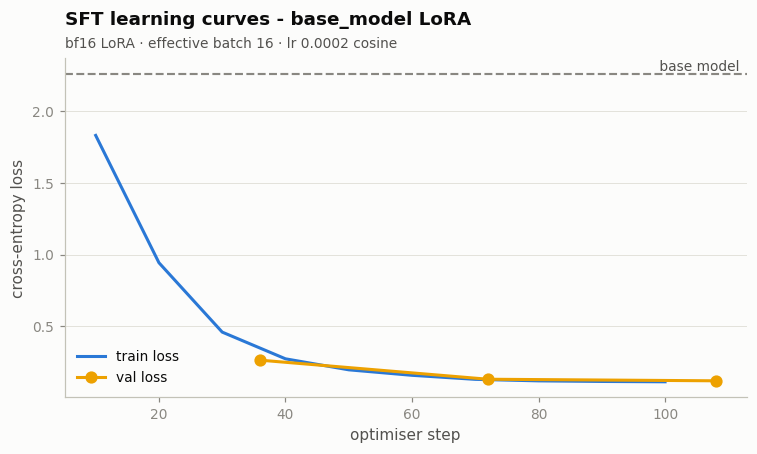

metrics saved -> reports/sft_metrics.json (notebook 05 reads this)


In [17]:
if SKIP_SFT:
    print('Part A skipped - trained adapter already present (FORCE_RETRAIN=True to redo)')
else:
    import json
    from pathlib import Path

    hist = trainer.state.log_history
    tr = [(h["step"], h["loss"]) for h in hist if "loss" in h]
    ev = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(*zip(*tr), color=C[0], linewidth=2, label="train loss")
    if ev:
        ax.plot(*zip(*ev), color=C[2], linewidth=2, marker="o", markersize=7, label="val loss")
    ax.axhline(base_eval["eval_loss"], color=INK["muted"], linewidth=1.4, linestyle="--")
    ax.text(0.99, base_eval["eval_loss"], " base model", va="bottom", ha="right",
            transform=ax.get_yaxis_transform(), fontsize=9, color=INK["secondary"])
    ax.legend()
    finish(ax, f"SFT learning curves - {cfg.base_model.split('/')[-1]} LoRA",
           subtitle=f"{'QLoRA 4-bit' if USE_QLORA else 'bf16 LoRA'} · effective batch "
                    f"{cfg.effective_batch_size} · lr {cfg.learning_rate} cosine",
           xlabel="optimiser step", ylabel="cross-entropy loss")
    save_fig(fig, "sft_learning_curves")
    plt.show()

    Path("reports").mkdir(exist_ok=True)
    Path("reports/sft_metrics.json").write_text(json.dumps({
        "base_model": cfg.base_model,
        "base_eval_loss": base_eval["eval_loss"],
        "final_eval_loss": ev[-1][1] if ev else None,
        "use_qlora": USE_QLORA,
        "log_history": hist,
    }, indent=2))
    print("metrics saved -> reports/sft_metrics.json (notebook 05 reads this)")
    persist('reports/sft_metrics.json')


### A.3 (Optional) learning-rate sweep

A compact sweep on a 128-example subset, one epoch each - enough signal to
confirm 2e-4 is in the basin without burning an hour. Off by default.

In [18]:
RUN_LR_SWEEP = False        # ~6 min extra on A100

if RUN_LR_SWEEP:
    sweep_losses = {}
    sub = train_ds.select(range(128))
    for lr in (1e-4, 2e-4, 4e-4):
        args = SFTConfig(output_dir=f"/tmp/sweep_{lr}", num_train_epochs=1,
                         per_device_train_batch_size=cfg.per_device_train_batch_size,
                         gradient_accumulation_steps=cfg.gradient_accumulation_steps,
                         learning_rate=lr, bf16=True, seed=cfg.seed, report_to=[],
                         eval_strategy="no", save_strategy="no", logging_steps=50,
                         **{seq_kw: cfg.max_seq_length})
        t = SFTTrainer(model=cfg.base_model, args=args, train_dataset=sub,
                       eval_dataset=val_ds, peft_config=cfg.to_peft_config())
        t.train()
        sweep_losses[lr] = t.evaluate()["eval_loss"]
        del t; torch.cuda.empty_cache()

    fig, ax = plt.subplots(figsize=(5.6, 3.2))
    xs = [str(k) for k in sweep_losses]; ys = list(sweep_losses.values())
    bars = ax.bar(xs, ys, color=C[0], width=0.5)
    for b, v in zip(bars, ys):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha="center",
                va="bottom", fontsize=9, color=INK["primary"])
    finish(ax, "LR sweep - val loss after 1 epoch on 128 examples",
           xlabel="learning rate", ylabel="eval loss")
    save_fig(fig, "lr_sweep")
    plt.show()
else:
    print("skipped (set RUN_LR_SWEEP = True to run the sweep)")

skipped (set RUN_LR_SWEEP = True to run the sweep)


### A.4 Sanity generation - base vs fine-tuned

The same prompt through the same weights with the adapter toggled off/on.
Expect the tuned answer to ground itself in named pathways and hedge less.

In [21]:
if SKIP_SFT:
    print('Part A skipped - trained adapter already present (FORCE_RETRAIN=True to redo)')
else:
    peft_model = trainer.model            # the LoRA-wrapped model
    peft_model.eval(); peft_model.config.use_cache = True

    prompt_msgs = val_raw[0]["messages"][:2]
    inputs = tokenizer.apply_chat_template(prompt_msgs, tokenize=True,
                                           add_generation_prompt=True,
                                           return_tensors="pt").to(peft_model.device)

    def generate():
        with torch.no_grad():
            out = peft_model.generate(**inputs, max_new_tokens=300, do_sample=False,
                                      pad_token_id=tokenizer.pad_token_id)
        return tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

    with peft_model.disable_adapter():
        base_answer = generate()
    tuned_answer = generate()

    print("PROMPT:", prompt_msgs[1]["content"][:200], "\n")
    print("=" * 30, "BASE", "=" * 30); print(base_answer[:600])
    print("=" * 30, "TUNED", "=" * 29); print(tuned_answer[:600])
    peft_model.config.use_cache = False


PROMPT: 
RETRIEVED DOCUMENTS (cite by number [N]):
[1] [NEPAL] curriculum | id:SC-001
    SC-001 Crime investigation and analysis: Following the model in class today, please create a spreadsheet with 15 OSINT 

============================== BASE ==============================
{
  "summary": "It's not too late to transition from blockchain to a viable software engineering career in Nepal, as the job market demands strong software skills like Python and Linux—skills you already have. While blockchain roles are limited locally, broader software engineering positions are available and well-aligned with your coursework and experience.",
  "pathways": [
    {
      "pathway_title": "Software Engineering Employment in Nepal",
      "rationale": "Your skills in Linux and Python align with current demand in Nepal's software industry, where companies seek practical developer
============================== TUNED =============================
{"summary": "Changing direction is common and rational

> **TensorBoard:** run `%load_ext tensorboard` then
> `%tensorboard --logdir reports/tb` in a fresh cell to watch losses live.

---
# Part B · Gesture policies (C3)

Demonstrations → LeRobot dataset → BC baseline → ACT → Diffusion. Batch sizes
below are A100-sized; halve them on a T4.

In [26]:
import subprocess, sys, pathlib, shutil
# Install LeRobot HERE (Part B only), not in the shared deps cell: it pins
# torch<2.8 / torchvision<0.23 which breaks the LLM stack. By now Part A's
# adapter is trained + saved, so changing torch no longer matters.
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "lerobot==0.3.3"], check=True)

# Ensure the output directory exists
output_dir = pathlib.Path("data/demonstrations")
output_dir.mkdir(parents=True, exist_ok=True)

# Remove the demonstrations.jsonl file if it exists, as collect_demonstrations.py
# might be trying to create it and failing if it already exists.
demonstrations_file = output_dir / "demonstrations.jsonl"
if demonstrations_file.exists():
    print(f"Removing existing {demonstrations_file} before collecting new demonstrations.")
    demonstrations_file.unlink()

# Remove the hf_dataset artifact if it exists, as collect_demonstrations.py
# tries to create it and fails if it already exists. It could be a file or a directory.
hf_dataset_path = output_dir / "hf_dataset"
if hf_dataset_path.exists():
    print(f"Removing existing {hf_dataset_path} before collecting new demonstrations.")
    if hf_dataset_path.is_dir():
        shutil.rmtree(hf_dataset_path)
    elif hf_dataset_path.is_file():
        hf_dataset_path.unlink()
    else:
        # If it exists but is neither a file nor a directory, print a warning.
        print(f"Warning: {hf_dataset_path} exists but is neither a file nor a directory. Skipping removal.")

try:
    result = subprocess.run([sys.executable, "scripts/collect_demonstrations.py",
                             "--episodes", "25", "--out-dir", str(output_dir)],
                            check=True, capture_output=True, text=True)
    if result.stdout:
        print("collect_demonstrations.py stdout:")
        print(result.stdout)
    if result.stderr:
        print("collect_demonstrations.py stderr:")
        print(result.stderr)
except subprocess.CalledProcessError as e:
    print(f"Error running collect_demonstrations.py: {e}")
    if e.stdout:
        print("stdout:", e.stdout)
    if e.stderr:
        print("stderr:", e.stderr)
    raise # Re-raise the exception to stop execution as before

from drona.interaction.demonstration import DemonstrationDataset

demo = DemonstrationDataset.load_jsonl(demonstrations_file)
print("frames:", demo.total_frames, "| episodes:", len(demo.episodes))

# LeRobot is needed ONLY for the ACT/Diffusion policies (Part B extras). Its
# dependency chain (PyAV video utils) churns and can break on Colab even though
# our demonstrations contain no video at all. Fail soft: the BC and keyframe
# policies need none of this, so a broken lerobot must not block the notebook.
LEROBOT_OK = True
try:
    from drona.interaction.lerobot_dataset import build_lerobot_dataset
    build_lerobot_dataset(demo, repo_id="drona/gestures", fps=20,
                          root="data/lerobot/drona_gestures")
    print("LeRobotDataset ready -> data/lerobot/drona_gestures")
except Exception as exc:
    LEROBOT_OK = False
    SKIP_ACT = SKIP_DIFF = True
    print(f"\nLeRobot unavailable -> {type(exc).__name__}: {str(exc)[:140]}")
    print("Skipping ACT + Diffusion (optional Part B extras).")
    print("BC and keyframe policies still train, and the C3 evaluation compares")
    print("whichever policies exist - your results stay valid, just without the")
    print("ACT/Diffusion rows. To retry: pip uninstall -y av, reinstall lerobot,")
    print("then RESTART the runtime (av is a compiled module).")


Removing existing data/demonstrations/hf_dataset before collecting new demonstrations.


2026-07-18 21:11:13.467 | INFO     | drona.interaction.demonstration:load_jsonl:254 - Loaded 5000 frames from data/demonstrations/demonstrations.jsonl


collect_demonstrations.py stdout:
Recording 25 episodes for gesture: greet
  → 25 episodes recorded (38 frames each)
Recording 25 episodes for gesture: nod
  → 25 episodes recorded (24 frames each)
Recording 25 episodes for gesture: point
  → 25 episodes recorded (38 frames each)
Recording 25 episodes for gesture: idle
  → 25 episodes recorded (20 frames each)
Recording 25 episodes for gesture: listen
  → 25 episodes recorded (43 frames each)
Recording 25 episodes for gesture: farewell
  → 25 episodes recorded (37 frames each)

Demonstration dataset summary:
  Total episodes : 150
  Total frames   : 5000
  Gestures       : {'greet': 25, 'nod': 25, 'point': 25, 'idle': 25, 'listen': 25, 'farewell': 25}
  JSONL output   : data/demonstrations/demonstrations.jsonl
  HF dataset     : data/demonstrations/hf_dataset

Run ACT training with: python scripts/train_act.py

collect_demonstrations.py stderr:
2026-07-18 21:11:12 | INFO     | drona.interaction.demonstration:save_jsonl:230 - Saved 5000

### B.1 Behaviour-cloning MLP baseline (fast)

In [27]:
if SKIP_BC:
    print('BC baseline skipped - checkpoints already trained')
else:
    subprocess.run([sys.executable, "scripts/train_bc_gesture.py",
                    "--epochs", "300", "--seed", "0"], check=True)
persist('data/checkpoints/bc')


### B.1b Export the BC policies to deployment formats

Converts each trained BC checkpoint to **ONNX** (opset 17) + **TorchScript**
with a verified torch-parity check. These are the files the ROS2 `policy_node`
serves on the robot (via onnxruntime - no torch needed at deployment); the
export lands inside `data/checkpoints/bc/` so the artifact zip below carries it.

In [28]:
subprocess.run([sys.executable, "scripts/export_policies.py"], check=True)
persist('data/checkpoints/bc')


### B.2 ACT - the C3 headline model (~10-15 min on A100)

In [29]:
# LeRobot keeps moving its training entrypoint (lerobot.scripts.train ->
# lerobot.train -> a `lerobot-train` console script). Discover whichever the
# installed version actually provides, and surface its real stderr instead of a
# bare CalledProcessError so failures are diagnosable.
import importlib.util, shutil, subprocess, sys


def _find_lerobot_train():
    for mod in ("lerobot.scripts.train", "lerobot.train", "lerobot.scripts.lerobot_train"):
        try:
            if importlib.util.find_spec(mod) is not None:
                return ["-m", mod], mod
        except (ImportError, ModuleNotFoundError, ValueError):
            continue
    exe = shutil.which("lerobot-train")
    if exe:
        return [exe], "lerobot-train (console script)"
    return None, None


def _lerobot_train(args, what="training"):
    entry, name = _find_lerobot_train()
    if entry is None:
        raise RuntimeError(
            "No LeRobot training entrypoint found. Tried lerobot.scripts.train, "
            "lerobot.train, lerobot.scripts.lerobot_train and the lerobot-train "
            "console script. Check the installed lerobot version:  pip show lerobot")
    cmd = ([sys.executable, *entry] if entry[0] == "-m" else list(entry)) + args
    print(f"[{what}] using entrypoint: {name}")
    r = subprocess.run(cmd, text=True, capture_output=True)
    if r.stdout:
        print(r.stdout[-3000:])
    if r.returncode != 0:
        print("--- STDERR (last 4000 chars) ---")
        print((r.stderr or "")[-4000:])
        raise RuntimeError(f"lerobot {what} failed with exit {r.returncode} - see stderr above")
    return r


if SKIP_ACT:
    print('ACT skipped - checkpoint already trained')
else:
    ACT_STEPS = 2_000         # smoke run; raise to 20_000 for the full model
    ACT_BATCH = 64            # A100; use 32 on a T4
    try:
        _lerobot_train([
            "--dataset.repo_id=drona/gestures",
            "--dataset.root=data/lerobot/drona_gestures",
            "--policy.type=act",
            "--policy.chunk_size=10",
            "--policy.n_action_steps=10",
            "--policy.dim_model=256",
            f"--batch_size={ACT_BATCH}",
            f"--steps={ACT_STEPS}",
            "--output_dir=data/checkpoints/act",
            "--job_name=drona_act",
            "--device=cuda",
            "--wandb.enable=false"], what="ACT")
        persist('data/checkpoints/act')
    except Exception as exc:
        SKIP_ACT = True
        print(f"\nACT unavailable -> {type(exc).__name__}: {str(exc)[:120]}")
        print("Skipping ACT (lerobot/PyAV churn). Your BC and keyframe policies cover")
        print("C3; the evaluation compares whichever policies exist, so results stand.")


ACT skipped - checkpoint already trained


### B.3 Diffusion Policy ablation (~20-30 min on A100)

In [30]:
if SKIP_DIFF:
    print('Diffusion skipped - checkpoint already trained')
else:
    TRAIN_DIFFUSION = True    # set False to skip the ablation model
    DIFF_STEPS = 30_000
    DIFF_BATCH = 64

    if TRAIN_DIFFUSION:
        try:
            _lerobot_train([
                "--dataset.repo_id=drona/gestures",
                "--dataset.root=data/lerobot/drona_gestures",
                "--policy.type=diffusion",
                "--policy.horizon=16",
                "--policy.n_action_steps=8",
                "--policy.n_obs_steps=2",
                f"--batch_size={DIFF_BATCH}",
                f"--steps={DIFF_STEPS}",
                "--output_dir=data/checkpoints/diffusion",
                "--job_name=drona_diffusion",
                "--device=cuda",
                "--wandb.enable=false"], what="Diffusion")
            persist('data/checkpoints/diffusion')
        except Exception as exc:
            SKIP_DIFF = True
            print(f"\nDiffusion unavailable -> {type(exc).__name__}: {str(exc)[:120]}")
            print("Skipping Diffusion (lerobot/PyAV churn); the ablation arm is optional.")
    else:
        print("skipped")


Diffusion skipped - checkpoint already trained


### B.4 Quick in-sim smoke check

One rollout per gesture per policy - just to confirm every checkpoint loads
and acts. The full comparison with statistics happens in notebook 05.

In [31]:
from drona.interaction.act_policy import KeyframePolicy, LeRobotACTPolicy
from drona.interaction.bc_policy import BCGesturePolicy, checkpoint_exists
from drona.interaction.diffusion_policy import LeRobotDiffusionPolicy
from drona.interaction.sim_eval import evaluate_policy

def _ckpt_factory(cls, base):
    def f(g):
        for path in (f"{base}/{g}", base):
            try:
                return cls(path, device="cuda")
            except Exception:
                continue
        return KeyframePolicy(g)
    return f

policies = {"keyframe": lambda g: KeyframePolicy(g)}
if checkpoint_exists("greet"):
    policies["bc"] = lambda g: BCGesturePolicy(g)
if pathlib.Path("data/checkpoints/act").exists():
    policies["act"] = _ckpt_factory(LeRobotACTPolicy, "data/checkpoints/act")
if pathlib.Path("data/checkpoints/diffusion").exists():
    policies["diffusion"] = _ckpt_factory(LeRobotDiffusionPolicy, "data/checkpoints/diffusion")

for name, factory in policies.items():
    r = evaluate_policy(factory)
    print(f"{name:10s} success={r.success_rate:5.0%}  mean_jerk={r.mean_jerk:.4f}  "
          f"path={r.mean_path_length:.2f}")

2026-07-18 21:13:13.029 | INFO     | drona.interaction.sim_eval:evaluate_policy:166 - Sim eval [KeyframePolicy]: success=100%, mean_jerk=0.0005, mean_path=1.197
2026-07-18 21:13:13.150 | INFO     | drona.interaction.sim_eval:evaluate_policy:166 - Sim eval [BCGesturePolicy]: success=100%, mean_jerk=0.0005, mean_path=1.149


keyframe   success= 100%  mean_jerk=0.0005  path=1.20
bc         success= 100%  mean_jerk=0.0005  path=1.15


---
# Export all artifacts

One zip with the LoRA adapter and all policy checkpoints, matched to the repo
layout - unzip at the repo root on your PC and everything auto-loads.

In [33]:
import shutil, pathlib

STAGE = pathlib.Path("/tmp/drona_export"); STAGE.mkdir(exist_ok=True)
targets = {
    cfg.output_dir: cfg.output_dir,              # models/advising-lora
    "data/checkpoints/act": "data/checkpoints/act",
    "data/checkpoints/diffusion": "data/checkpoints/diffusion",
    "data/checkpoints/bc": "data/checkpoints/bc",  # incl. ONNX/TorchScript exports
    "reports/sft_metrics.json": "reports/sft_metrics.json",
}
for src, rel in targets.items():
    p = pathlib.Path(src)
    if p.is_dir():
        shutil.copytree(p, STAGE / rel, dirs_exist_ok=True)
    elif p.is_file():
        (STAGE / rel).parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(p, STAGE / rel)

base = "/content" if pathlib.Path("/content").is_dir() else "."
zip_path = shutil.make_archive(f"{base}/drona_trained_models", "zip", STAGE)
print("zipped:", zip_path, "->", round(pathlib.Path(zip_path).stat().st_size / 1e6, 1), "MB")
if DRIVE is not None:
    shutil.copy2(zip_path, DRIVE / "drona_trained_models.zip")
    print("zip also saved to Drive - safe even if the download is missed")

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print("not on Colab - grab the zip from the path above")
print("\nOn your PC:  unzip drona_trained_models.zip -d <repo root>")
print("Serve the adapter directly (any GPU) with LLM_BACKEND=transformers in .env,")
print("or convert to GGUF for Ollama (docs/COLAB_TRAINING_GUIDE.md section 4).")

zipped: /content/drona_trained_models.zip -> 1227.8 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


On your PC:  unzip drona_trained_models.zip -d <repo root>
Serve the adapter directly (any GPU) with LLM_BACKEND=transformers in .env,
or convert to GGUF for Ollama (docs/COLAB_TRAINING_GUIDE.md section 4).


## Reproducibility record

In [34]:
import subprocess, sys, platform, pathlib, torch, transformers, peft, trl, datasets

versions = {
    "python": platform.python_version(), "torch": torch.__version__,
    "transformers": transformers.__version__, "peft": peft.__version__,
    "trl": trl.__version__, "datasets": datasets.__version__,
    "cuda": torch.version.cuda, "gpu": torch.cuda.get_device_name(0),
    "seed": cfg.seed,
}
for k, v in versions.items():
    print(f"{k:14s} {v}")

freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"],
                        capture_output=True, text=True).stdout
pathlib.Path("reports/train_env.txt").write_text(freeze)
print("\nfull environment frozen -> reports/train_env.txt")

python         3.12.13
torch          2.11.0+cu128
transformers   5.13.1
peft           0.19.1
trl            1.8.0
datasets       5.0.0
cuda           12.8
gpu            NVIDIA A100-SXM4-40GB
seed           230352

full environment frozen -> reports/train_env.txt


---
**Next:** [05 · Model Evaluation & Comparison](05_model_evaluation_comparison.ipynb) -
score every model on the C1-C4 metrics and pick the winners.